In [31]:
!pip install yfinance 

In [6]:
# ============================================================
# PROJECT: Investment Risk & Volatility Monitor - AlphaPulse
# WEEK 1: Data Acquisition & Cleaning
# ============================================================

# -----------------------------
# Import Required Libraries
# -----------------------------

import pandas as pd
import yfinance as yf


# -----------------------------
# STEP 1: Portfolio Planning
# -----------------------------
# Create diversified portfolio with sector classification
# This helps later in Power BI for sector-wise analysis

portfolio = {
    "AAPL": "Tech",
    "MSFT": "Tech",
    "GOOGL": "Tech",
    "META": "Tech",
    "AMZN": "E-commerce",
    "JPM": "Banking",
    "BAC": "Banking",
    "JNJ": "Healthcare",
    "XOM": "Energy",
    "TSLA": "Auto/Tech",
    "^GSPC": "Index"  # S&P 500 benchmark
}

# Extract only ticker symbols into a list
tickers = list(portfolio.keys())

# Convert sector mapping into DataFrame
sector_df = pd.DataFrame(
    portfolio.items(),
    columns=["Ticker", "Sector"]
)

# Save sector mapping for Power BI usage
sector_df.to_csv("portfolio_sectors.csv", index=False)

print("STEP 1 COMPLETED: Portfolio defined and sector file saved.\n")


# -----------------------------
# STEP 2: Data Acquisition
# -----------------------------
# Download historical market data from Yahoo Finance
# auto_adjust=True ensures splits & dividends are handled

print("Downloading historical stock data...")

raw_data = yf.download(
    tickers,
    start="2018-01-01",
    end="2024-01-01",
    auto_adjust=True,   # Adjust prices for corporate actions
    progress=False
)

# Extract Adjusted Close prices only
# These are financially correct closing prices
prices = raw_data["Close"].copy()

print("STEP 2 COMPLETED: Data downloaded successfully.\n")


# -----------------------------
# STEP 3: Data Cleaning & Quality Validation
# -----------------------------

# 1️⃣ Check missing values
print("Checking missing values before cleaning:")
print(prices.isnull().sum(), "\n")

# Remove rows with missing values
prices.dropna()

# 2️⃣ Ensure Date index is in proper datetime format
if not isinstance(prices.index, pd.DatetimeIndex):
    prices.index = pd.to_datetime(prices.index)

# 3️⃣ Check for duplicate rows
duplicate_count = prices.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

# Remove duplicates if any
prices.drop_duplicates()

# 4️⃣ Final dataset validation summary
print("\nDataset shape after cleaning:", prices.shape)
print("Date range:", prices.index.min(), "to", prices.index.max())

# Save cleaned dataset
prices.to_csv("01_clean_prices.csv")

print("\nSTEP 3 COMPLETED: Cleaned dataset saved as 01_clean_prices.csv")
print("\nWEEK 1 DATA PIPELINE EXECUTED SUCCESSFULLY ✅")

STEP 1 COMPLETED: Portfolio defined and sector file saved.

STEP 2 COMPLETED: Data downloaded successfully.

Checking missing values before cleaning:
Ticker
AAPL     0
AMZN     0
BAC      0
GOOGL    0
JNJ      0
JPM      0
META     0
MSFT     0
TSLA     0
XOM      0
^GSPC    0
dtype: int64 

Duplicate rows found: 0

Dataset shape after cleaning: (1509, 11)
Date range: 2018-01-02 00:00:00 to 2023-12-29 00:00:00

STEP 3 COMPLETED: Cleaned dataset saved as 01_clean_prices.csv

WEEK 1 DATA PIPELINE EXECUTED SUCCESSFULLY ✅


In [7]:
# ============================================================
# WEEK 2: Quantitative Analysis
# Risk Modeling + Monte Carlo Simulation + Statistical Validation
# ============================================================

# ------------------------------------------------------------
# Import Required Libraries
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

print("Libraries Imported Successfully")


Libraries Imported Successfully


Log Returns Calculated & Saved


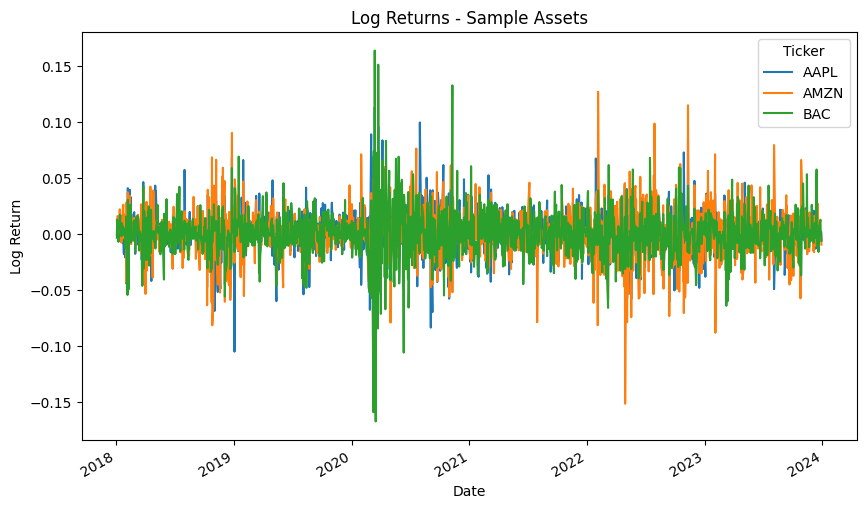

In [8]:
# ------------------------------------------------------------
# Step 2: Calculate Log Returns
# Formula: log(Pt / Pt-1)
# ------------------------------------------------------------

log_returns = np.log(prices / prices.shift(1))
log_returns = log_returns.dropna()

log_returns.to_csv("02_log_returns.csv")

print("Log Returns Calculated & Saved")


# ------------------------------------------------------------
# Visualization 1: Log Returns (Sample 3 Assets)
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
log_returns.iloc[:, :3].plot(ax=plt.gca())
plt.title("Log Returns - Sample Assets")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()



Rolling Volatility Calculated & Saved


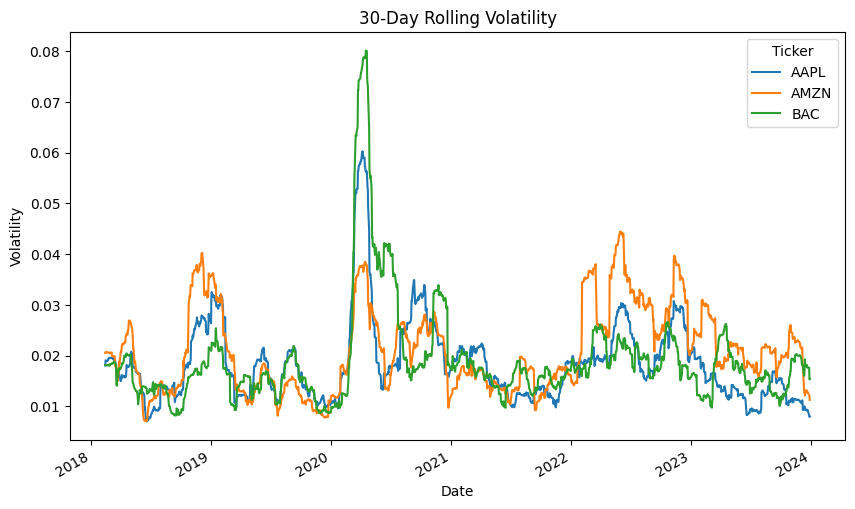

In [9]:
# ------------------------------------------------------------
# Step 3: Rolling Volatility (30-Day)
# Measures short-term market uncertainty
# ------------------------------------------------------------

rolling_vol = log_returns.rolling(window=30).std()
rolling_vol.to_csv("03_rolling_volatility.csv")

print("Rolling Volatility Calculated & Saved")


# ------------------------------------------------------------
# Visualization 2: Rolling Volatility (30-Day)
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
rolling_vol.iloc[:, :3].plot(ax=plt.gca())
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.savefig("02_rolling_volatility.png", dpi=300, bbox_inches='tight')
plt.show()



Correlation Matrix:
Ticker      AAPL      AMZN       BAC     GOOGL       JNJ       JPM      META  \
Ticker                                                                         
AAPL    1.000000  0.625221  0.456982  0.676889  0.390861  0.463476  0.565809   
AMZN    0.625221  1.000000  0.330763  0.672946  0.240077  0.310040  0.603323   
BAC     0.456982  0.330763  1.000000  0.455929  0.395469  0.907825  0.339391   
GOOGL   0.676889  0.672946  0.455929  1.000000  0.353125  0.457410  0.656720   
JNJ     0.390861  0.240077  0.395469  0.353125  1.000000  0.413566  0.230804   
JPM     0.463476  0.310040  0.907825  0.457410  0.413566  1.000000  0.335556   
META    0.565809  0.603323  0.339391  0.656720  0.230804  0.335556  1.000000   
MSFT    0.751705  0.697864  0.464405  0.768711  0.416911  0.469093  0.604377   
TSLA    0.471537  0.425146  0.294252  0.403684  0.123905  0.285725  0.339979   
XOM     0.332798  0.194249  0.604916  0.328010  0.318252  0.589158  0.200592   
^GSPC   0.797389  0

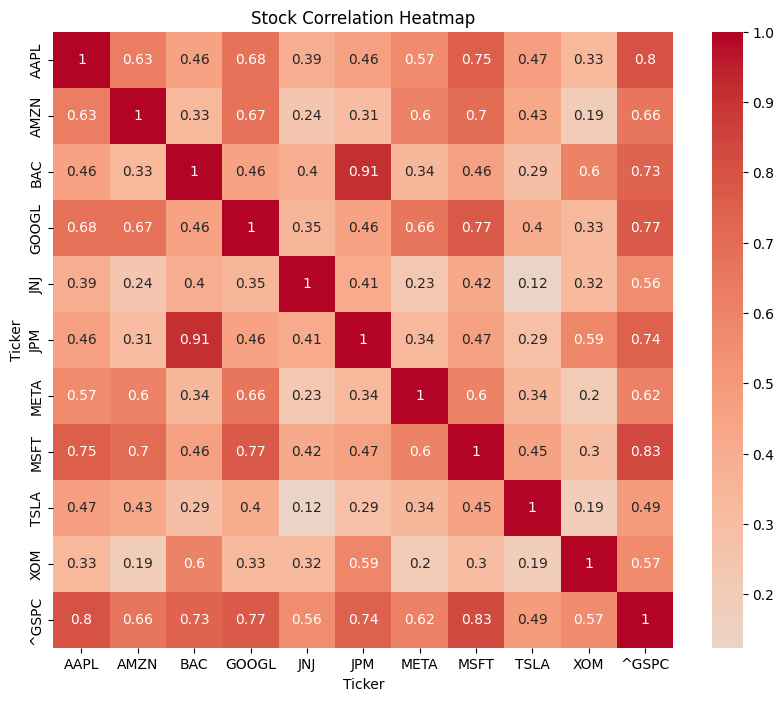

In [10]:
# ------------------------------------------------------------
# STEP 3B: Correlation Matrix
# ------------------------------------------------------------

# Calculate correlation between all assets
correlation_matrix = log_returns.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)



# ------------------------------------------------------------
# Visualization : CORRELATION HEATMAP
# Shows relationship between stocks
# ------------------------------------------------------------

correlation_matrix = log_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Stock Correlation Heatmap")
plt.savefig("01_correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

VaR (95%) Calculated & Saved
Empty DataFrame
Columns: [VaR_95]
Index: []


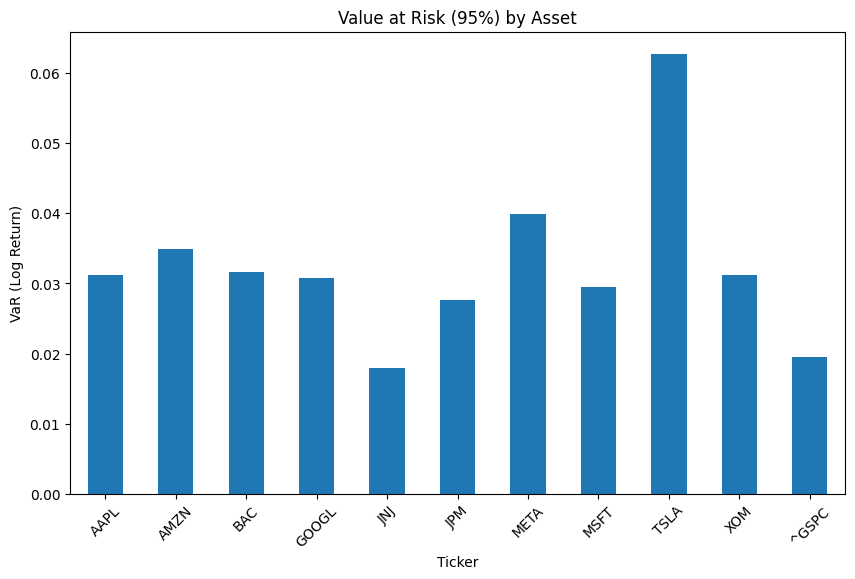

In [37]:
# ------------------------------------------------------------
# Step 4: Value at Risk (95%)
# Measures worst expected loss at 5% confidence
# ------------------------------------------------------------

confidence_level = 0.05
var_95 = abs(log_returns.quantile(confidence_level))

var_df = pd.DataFrame(var_95, columns=["VaR_95"])
var_df.to_csv("04_var_95.csv")

print("VaR (95%) Calculated & Saved")
print(var_df)


# ------------------------------------------------------------
# Visualization 3: VaR Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
var_95.plot(kind='bar')
plt.title("Value at Risk (95%) by Asset")
plt.ylabel("VaR (Log Return)")
plt.xticks(rotation=45)

plt.show()



Portfolio Weights:
{'AAPL': np.float64(0.09090909090909091), 'AMZN': np.float64(0.09090909090909091), 'BAC': np.float64(0.09090909090909091), 'GOOGL': np.float64(0.09090909090909091), 'JNJ': np.float64(0.09090909090909091), 'JPM': np.float64(0.09090909090909091), 'META': np.float64(0.09090909090909091), 'MSFT': np.float64(0.09090909090909091), 'TSLA': np.float64(0.09090909090909091), 'XOM': np.float64(0.09090909090909091), '^GSPC': np.float64(0.09090909090909091)}

Monte Carlo Simulation Completed


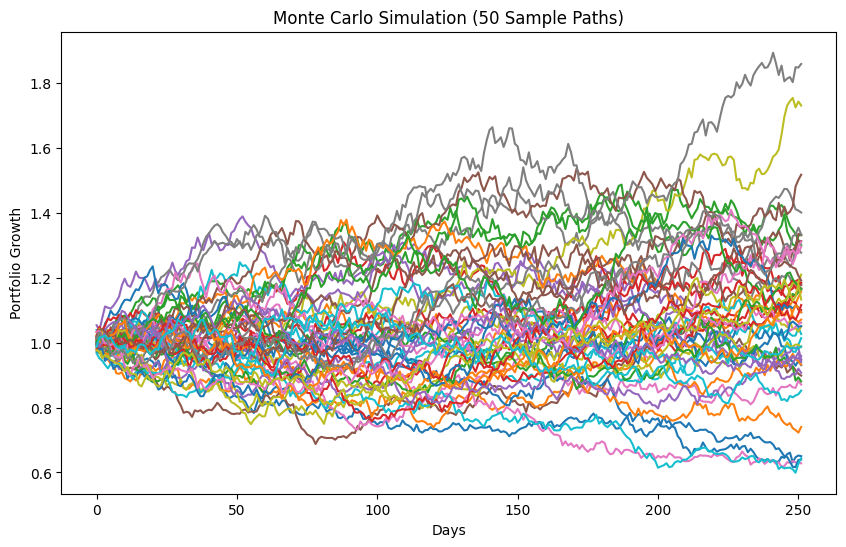

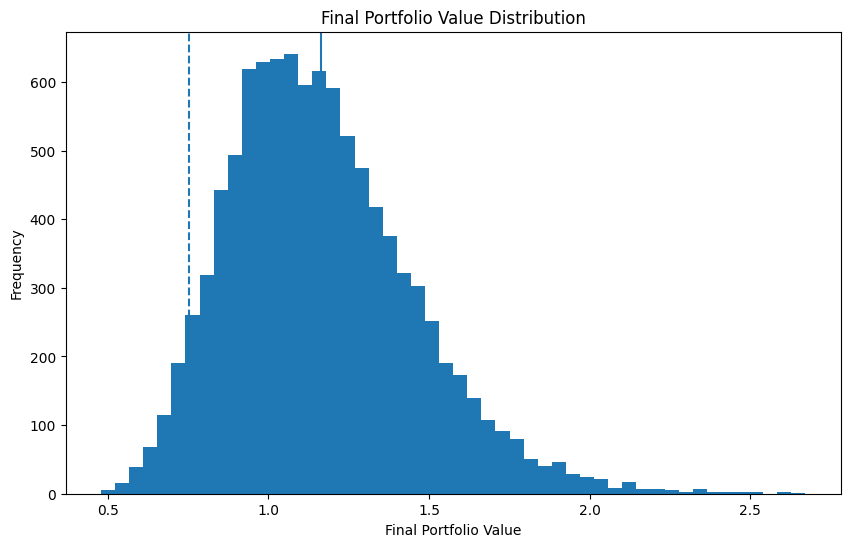

Monte Carlo Results Saved


In [12]:
# ------------------------------------------------------------
# Step 5: Portfolio Monte Carlo Simulation
# Correlated Multi-Asset Simulation
# ------------------------------------------------------------

# Equal Weights Portfolio
num_assets = len(log_returns.columns)
weights = np.repeat(1/num_assets, num_assets)

print("\nPortfolio Weights:")
print(dict(zip(log_returns.columns, weights)))

# Mean Vector & Covariance Matrix
mean_returns = log_returns.mean()
cov_matrix = log_returns.cov()

# Simulation Parameters
days = 252            # 1 trading year
simulations = 10000   # number of paths

# Generate Correlated Random Returns
simulated_returns = np.random.multivariate_normal(
    mean_returns,
    cov_matrix,
    (days, simulations)
)

# Portfolio Returns
portfolio_returns = np.dot(simulated_returns, weights)

# Convert to Growth Paths
portfolio_growth = np.cumprod(1 + portfolio_returns, axis=0)

print("\nMonte Carlo Simulation Completed")


# ------------------------------------------------------------
# Visualization 4: Monte Carlo Paths (50 Paths)
# ------------------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(portfolio_growth[:, :50])
plt.title("Monte Carlo Simulation (50 Sample Paths)")
plt.xlabel("Days")
plt.ylabel("Portfolio Growth")
plt.savefig("04_monte_carlo_paths.png", dpi=300, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# Visualization 5: Final Portfolio Value Distribution
# ------------------------------------------------------------

final_values = portfolio_growth[-1]

plt.figure(figsize=(10,6))
plt.hist(final_values, bins=50)
plt.title("Final Portfolio Value Distribution")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")

# 5% Worst Case Line
plt.axvline(np.percentile(final_values, 5), linestyle='dashed')

# Mean Line
plt.axvline(np.mean(final_values), linestyle='solid')

plt.savefig("05_final_portfolio_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# Step 6: Save Monte Carlo Results
# ------------------------------------------------------------

mc_results = pd.DataFrame(final_values,
                          columns=["Final_Portfolio_Value"])

mc_results.to_csv("05_monte_carlo_results.csv")

print("Monte Carlo Results Saved")




========== Statistical Validation ==========

Historical Returns Statistics
Mean: 0.0006216779844575655
Std Dev: 0.015320923218645156
Skewness: -0.6914961268421681
Kurtosis: 8.244841015899253

Simulated Returns Statistics
Mean: 0.0006166210732413089
Std Dev: 0.015323880039630701
Skewness: -0.001188084186665898
Kurtosis: -0.0020507268055878214


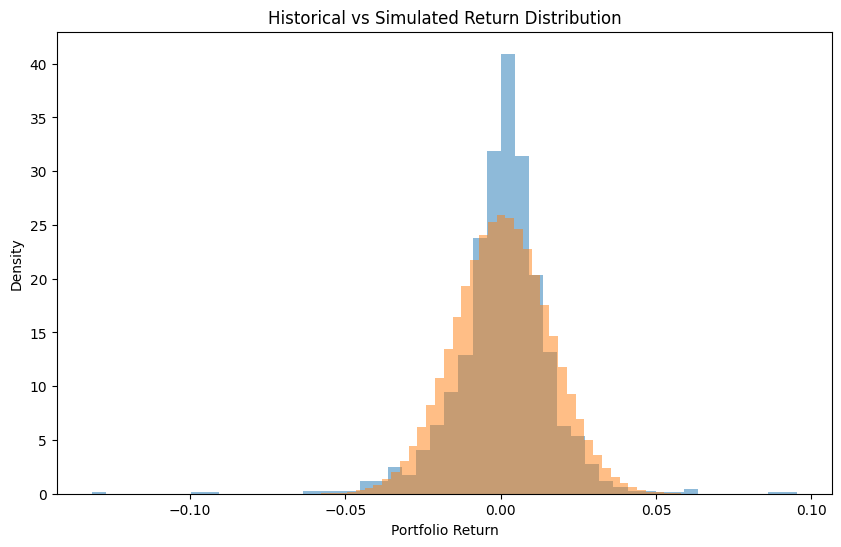

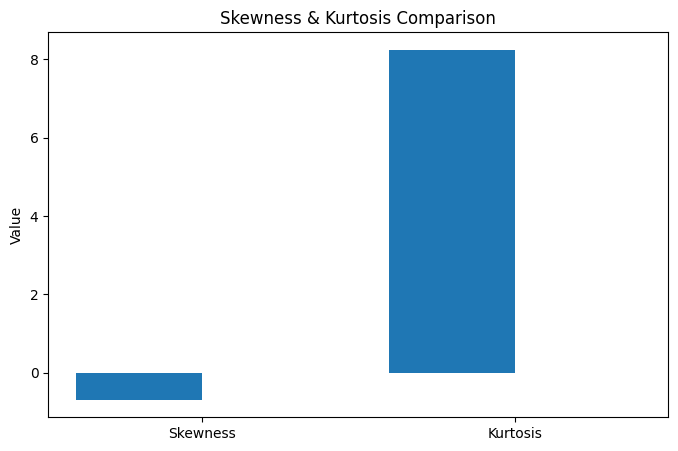

In [39]:
# ------------------------------------------------------------
# Step 7: Statistical Validation
# Compare Historical vs Simulated Distribution
# ------------------------------------------------------------

print("\n========== Statistical Validation ==========")

# Historical Portfolio Returns
historical_portfolio_returns = np.dot(log_returns, weights)

# Flatten Simulated Returns
simulated_flat = portfolio_returns.flatten()

print("\nHistorical Returns Statistics")
print("Mean:", np.mean(historical_portfolio_returns))
print("Std Dev:", np.std(historical_portfolio_returns))
print("Skewness:", skew(historical_portfolio_returns))
print("Kurtosis:", kurtosis(historical_portfolio_returns))

print("\nSimulated Returns Statistics")
print("Mean:", np.mean(simulated_flat))
print("Std Dev:", np.std(simulated_flat))
print("Skewness:", skew(simulated_flat))
print("Kurtosis:", kurtosis(simulated_flat))


# ------------------------------------------------------------
# Visualization 6: Historical vs Simulated Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(historical_portfolio_returns, bins=50,
         alpha=0.5, density=True)

plt.hist(simulated_flat, bins=50,
         alpha=0.5, density=True)

plt.title("Historical vs Simulated Return Distribution")
plt.xlabel("Portfolio Return")
plt.ylabel("Density")
plt.show()


# ------------------------------------------------------------
# Visualization 7: Skewness & Kurtosis Comparison
# ------------------------------------------------------------

metrics = ["Skewness", "Kurtosis"]

historical_stats = [
    skew(historical_portfolio_returns),
    kurtosis(historical_portfolio_returns)
]

simulated_stats = [
    skew(simulated_flat),
    kurtosis(simulated_flat)
]

x = np.arange(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, historical_stats, width=0.4)
plt.bar(x + 0.2, simulated_stats, width=0.4)

plt.xticks(x, metrics)
plt.title("Skewness & Kurtosis Comparison")
plt.ylabel("Value")
plt.show()


In [40]:
# ------------------------------------------------------------
# Step 8: Save Validation Summary
# ------------------------------------------------------------

validation_df = pd.DataFrame({
    "Metric": ["Mean", "Std Dev", "Skewness", "Kurtosis"],
    "Historical": [
        np.mean(historical_portfolio_returns),
        np.std(historical_portfolio_returns),
        skew(historical_portfolio_returns),
        kurtosis(historical_portfolio_returns)
    ],
    "Simulated": [
        np.mean(simulated_flat),
        np.std(simulated_flat),
        skew(simulated_flat),
        kurtosis(simulated_flat)
    ]
})

validation_df.to_csv("06_statistical_validation.csv", index=False)

print("\nStatistical Validation Saved")
print("\n✅ WEEK 2 COMPLETED SUCCESSFULLY")


Statistical Validation Saved

✅ WEEK 2 COMPLETED SUCCESSFULLY


In [47]:
# ============================================================
# WEEK 3: Power BI Data Preparation
# Visual Storytelling Dataset for What-If Analysis
# ============================================================


# ------------------------------------------------------------
# STEP 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# STEP 2: Load Week 1 & Week 2 Output Files
# ------------------------------------------------------------


prices = pd.read_csv("01_clean_prices.csv", index_col=0)

# Convert index to datetime
prices.index = pd.to_datetime(prices.index)


# Log returns dataset
log_returns = pd.read_csv("02_log_returns.csv", index_col=0)

# Convert index to datetime
log_returns.index = pd.to_datetime(log_returns.index)


# Sector mapping dataset
sectors = pd.read_csv("portfolio_sectors.csv")

print(" All files loaded successfully")


# ------------------------------------------------------------
# STEP 3: Convert Log Returns to Long Format
# Power BI prefers long format instead of wide format
# ------------------------------------------------------------

returns_long = log_returns.reset_index().melt(
    id_vars="Date",      # keep Date column fixed
    var_name="Ticker",   # stock name column
    value_name="Log_Return"  # return values
)

print(" Log returns converted to long format")


# ------------------------------------------------------------
# STEP 4: Convert Prices to Long Format
# ------------------------------------------------------------

prices_long = prices.reset_index().melt(
    id_vars="Date",
    var_name="Ticker",
    value_name="Adj_Close"
)

print(" Prices converted to long format")



# ------------------------------------------------------------
# STEP 5: Merge Sector & Prices Information
# This allows sector-based visualizations in Power BI
# ------------------------------------------------------------

returns_long = returns_long.merge(
    sectors, 
    on="Ticker",
    how="left"
)

# Merge Price Data
returns_long = returns_long.merge(
    prices_long,
    on=["Date","Ticker"],
    how="left"
)

print(" Sector & Prices information added")


# ------------------------------------------------------------
# STEP 6: Calculate Equal Weight Portfolio Contribution
# Each asset contributes equally to the portfolio
# ------------------------------------------------------------

num_assets = log_returns.shape[1]

equal_weight = 1 / num_assets

returns_long["Weight"] = equal_weight


# ------------------------------------------------------------
# STEP 7: Calculate Weighted Portfolio Return
# This represents contribution of each asset
# ------------------------------------------------------------

returns_long["Weighted_Return"] = returns_long["Log_Return"] * returns_long["Weight"]

print(" Weighted portfolio returns calculated")


# ------------------------------------------------------------
# STEP 8: Save Dataset for Power BI
# ------------------------------------------------------------

returns_long.to_csv("07_powerbi_dataset.csv", index=False)

print(" Dataset saved successfully as: 07_powerbi_dataset.csv")


# ------------------------------------------------------------
# STEP 9: Preview Data
# ------------------------------------------------------------

print("\nSample Data:")
print(returns_long.head())


print("\n WEEK 3 DATA PREPARATION COMPLETED SUCCESSFULLY")

 All files loaded successfully
 Log returns converted to long format
 Prices converted to long format
 Sector & Prices information added
 Weighted portfolio returns calculated
 Dataset saved successfully as: 07_powerbi_dataset.csv

Sample Data:
        Date Ticker  Log_Return Sector  Adj_Close    Weight  Weighted_Return
0 2018-01-03   AAPL   -0.000174   Tech  40.297161  0.090909        -0.000016
1 2018-01-04   AAPL    0.004634   Tech  40.484337  0.090909         0.000421
2 2018-01-05   AAPL    0.011321   Tech  40.945267  0.090909         0.001029
3 2018-01-08   AAPL   -0.003721   Tech  40.793179  0.090909        -0.000338
4 2018-01-09   AAPL   -0.000115   Tech  40.788498  0.090909        -0.000010

 WEEK 3 DATA PREPARATION COMPLETED SUCCESSFULLY


In [2]:
# ============================================================
# WEEK 4: Financial Accuracy Check
# Validate Portfolio Metrics using Benchmark Comparison
# ============================================================

# ------------------------------------------------------------
# Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# STEP 1: Load Log Returns Dataset (Week 2 Output)
# ------------------------------------------------------------

# Load log returns generated in Week 2
log_returns = pd.read_csv("02_log_returns.csv", index_col=0)

# Convert index to datetime
log_returns.index = pd.to_datetime(log_returns.index)

print("Log Returns Data Loaded Successfully")
print("Dataset Shape:", log_returns.shape)


# ------------------------------------------------------------
# STEP 2: Calculate Portfolio Daily Returns
# ------------------------------------------------------------

# Number of assets in portfolio
num_assets = len(log_returns.columns)

# Equal weights assumption
weights = np.repeat(1/num_assets, num_assets)

# Calculate daily portfolio return
portfolio_returns = np.dot(log_returns, weights)

# Convert to pandas series
portfolio_series = pd.Series(
    portfolio_returns,
    index=log_returns.index,
    name="Portfolio_Return"
)

print("\nPortfolio Daily Returns Calculated")


# ------------------------------------------------------------
# STEP 3: Extract Benchmark (S&P 500)
# ------------------------------------------------------------

# S&P500 ticker used in project
benchmark_returns = log_returns["^GSPC"]

print("\nBenchmark Returns Extracted")


# ------------------------------------------------------------
# STEP 4: Calculate Risk Metrics
# ------------------------------------------------------------

# Portfolio metrics
portfolio_mean = portfolio_series.mean()
portfolio_vol = portfolio_series.std()
portfolio_var = portfolio_series.quantile(0.05)

# Benchmark metrics
benchmark_mean = benchmark_returns.mean()
benchmark_vol = benchmark_returns.std()
benchmark_var = benchmark_returns.quantile(0.05)

print("\nRisk Metrics Calculated")


# ------------------------------------------------------------
# STEP 5: Create Benchmark Comparison Table
# ------------------------------------------------------------

benchmark_check = pd.DataFrame({
    
    "Metric": [
        "Average Return",
        "Volatility",
        "Value at Risk (95%)"
    ],
    
    "Portfolio": [
        portfolio_mean,
        portfolio_vol,
        portfolio_var
    ],
    
    "S&P 500 Benchmark": [
        benchmark_mean,
        benchmark_vol,
        benchmark_var
    ]
})

print("\nBenchmark Comparison Table")
print(benchmark_check)


# ------------------------------------------------------------
# STEP 6: Save Validation File
# ------------------------------------------------------------

benchmark_check.to_csv("08_benchmark_check.csv", index=False)

print("\nBenchmark Validation File Saved Successfully")

Log Returns Data Loaded Successfully
Dataset Shape: (1508, 11)

Portfolio Daily Returns Calculated

Benchmark Returns Extracted

Risk Metrics Calculated

Benchmark Comparison Table
                Metric  Portfolio  S&P 500 Benchmark
0       Average Return   0.000622           0.000378
1           Volatility   0.015326           0.013075
2  Value at Risk (95%)  -0.024222          -0.019554

Benchmark Validation File Saved Successfully


In [3]:
plt.savefig("01_correlation_heatmap.png", dpi=300, bbox_inches='tight')


NameError: name 'plt' is not defined